In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from recommender import RecommendationEngine
from try_on import run_tryon_pipeline
from size_estimation import BodyMeasurementSystem

from transformers import CLIPProcessor, CLIPModel
import torch
import torch.nn.functional as F
import json
from PIL import Image

c:\Users\shril\Documents\GitHub\Internship\multi-community-e-commerce-platform\venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Sample inputs
person_path = "person/p1.jpg"
product_id = 1
csv_path = "csv1.csv"

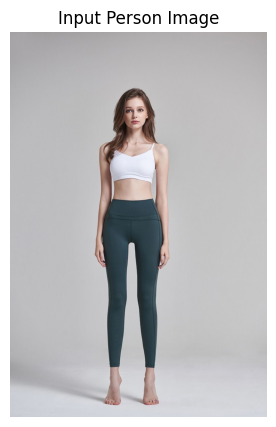

In [3]:
img = cv2.imread(person_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Input Person Image")
plt.axis("off")
plt.show()

In [4]:
output_path = run_tryon_pipeline(
    person_path_input=person_path,
    product_id_input=product_id,
    output_path_input="final_tryon_output.png"
)


Type: TOP
Length: full_length
 DONE — structured try-on completed


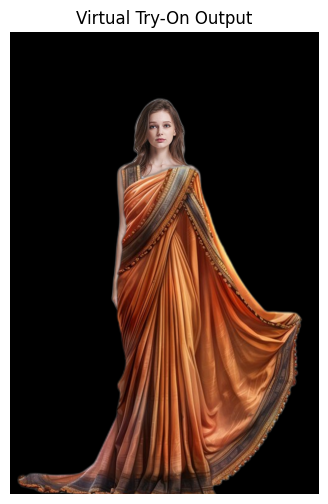

In [5]:
result = cv2.imread(output_path)
result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(result)
plt.title("Virtual Try-On Output")
plt.axis("off")
plt.show()


In [6]:
system = BodyMeasurementSystem()

measurement_result = system.get_measurements_and_size(
    image_path=person_path,
    height_cm=183,
    gender="female"
)

measurement_result

{'shoulder_width': '37.9 cm',
 'torso_length': '55.1 cm',
 'hip_width': '22.3 cm',
 'recommended_size': 'M'}

In [7]:
for key, value in measurement_result.items():
    print(f"{key}: {value}")


shoulder_width: 37.9 cm
torso_length: 55.1 cm
hip_width: 22.3 cm
recommended_size: M


In [8]:
engine = RecommendationEngine(csv_path)

user_profile = {
    "community": "hindu",
    "category": "saree",
    "price_range": (500, 3000)
}


In [9]:
results = engine.recommend(user_profile)
results

,product_id,name,category,community,family,price,rating,image_path,score,explanation
12,13,red_plane_saree,saree,hindu,garnment,2500.0,4.5,img1.png,100,community + category + price match
0,1,orange_traditional_saree,saree,hindu,garnment,2000.0,3.0,img2.jpg,100,community + category + price match
1,2,purple_stylish_saree,saree,hindu,garnment,5000.0,4.0,img3.jpg,85,community + category match
3,4,red_designer_saree,saree,hindu,garnment,6500.0,2.8,img5.png,85,community + category match
32,33,dark_green_lehenga_set,lehenga,hindu,garnment,5000.0,4.9,img33.jpg,70,community match


In [10]:
results[[
    "product_id",
    "name",
    "category",
    "price",
    "rating",
    "explanation"
]]

,product_id,name,category,price,rating,explanation
12,13,red_plane_saree,saree,2500.0,4.5,community + category + price match
0,1,orange_traditional_saree,saree,2000.0,3.0,community + category + price match
1,2,purple_stylish_saree,saree,5000.0,4.0,community + category match
3,4,red_designer_saree,saree,6500.0,2.8,community + category match
32,33,dark_green_lehenga_set,lehenga,5000.0,4.9,community match


In [11]:
top = results.iloc[0]

print("Top Recommended Product:")
print("Name:", top["name"])
print("Price:", top["price"])
print("Rating:", top["rating"])
print("Reason:", top["explanation"])


Top Recommended Product:
Name: red_plane_saree
Price: 2500.0
Rating: 4.5
Reason: community + category + price match


In [12]:
model_name = "patrickjohncyh/fashion-clip"
device = "cpu"

clip_model = CLIPModel.from_pretrained(model_name).to(device)
clip_model.eval()

clip_processor = CLIPProcessor.from_pretrained(model_name)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 2706.85it/s]


In [13]:
embedding_csv = "category_embeddings.csv"

df = pd.read_csv(embedding_csv)

categories = df["category"].tolist()

category_embeddings = torch.tensor(
    [json.loads(x) for x in df["embedding"]],
    dtype=torch.float32
)

category_embeddings = F.normalize(category_embeddings, dim=-1)

print("Loaded categories:", len(categories))

Loaded categories: 24


In [14]:
image_path = r"classifier_img\c1.jpeg"

def classify_image(image_path, top_k=1):
    image = Image.open(image_path).convert("RGB")

    inputs = clip_processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = clip_model.vision_model(
            pixel_values=inputs["pixel_values"]
        )

        image_emb = clip_model.visual_projection(outputs.pooler_output)
        image_emb = F.normalize(image_emb, dim=-1)

    similarity = image_emb @ category_embeddings.T

    scores, indices = torch.topk(similarity[0], top_k)

    return [
        (categories[idx.item()], float(score.item() * 100))
        for score, idx in zip(scores, indices)
    ]

In [15]:
results = classify_image(image_path, 1)

print("\nBEST MATCH:\n")
print(results[0][0], f"({results[0][1]:.2f}%)")


BEST MATCH:

saree (31.93%)
